CAPSTONE PROJECT -- *** Brain MRI Images for Brain Tumor Detection ***

<h1 style="text-align: center; color: green;">
Brain Tumor Detection Using Deep Learning
</h1>

Step 1: Importing Required Libraries

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import ResNet101V2, DenseNet201
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

C:\Users\Ramachandran\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Step 2: Loading the Dataset Path

In [4]:
dataset = r"D:\AI and DL\Capstone Project\Brain_tumor_dataset"

STEP 3 — Create Image Data Generators

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255,
                                   validation_split=0.2,
                                   rotation_range=15,
                                   zoom_range=0.1,
                                   horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)

In [14]:
train_generator = train_datagen.flow_from_directory(dataset,
                                                    target_size=(224, 224),
                                                    batch_size=32,
                                                    class_mode='binary',
                                                    subset='training',
                                                    shuffle=True)
val_generator = val_datagen.flow_from_directory(dataset,
                                                target_size=(224, 224),
                                                batch_size=32,
                                                class_mode='binary',
                                                subset='validation',
                                                shuffle=False)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [19]:
print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Classes:", train_generator.class_indices)

Training samples: 203
Validation samples: 50
Classes: {'no': 0, 'yes': 1}


STEP 4 — Load Pretrained Model

In [16]:
base_model = ResNet101V2(weights='imagenet',
                         include_top=False,
                         input_shape=(224, 224, 3))

base_model.trainable = False

171317808/171317808 ━━━━━━━━━━━━━━━━━━━━ 76s 0us/step 


In [17]:
base_model.summary()

Model: "resnet101v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_preact_bn        │ (None, 56, 56, 64)        │             256 │ pool1_pool[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_preact_relu      │ (None, 56, 56, 64)        │               0 │ conv2_block1_preact_bn[0]… │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,096 │ conv2_block1_preact_relu[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_pad            │ (None, 58, 58, 64)        │               0 │ conv2_block1_1_relu[0][0]  │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,864 │ conv2_block1_2_pad[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │               

 Total params: 42,626,560 (162.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 42,626,560 (162.61 MB)

 Step 5:Show Sample Training Images

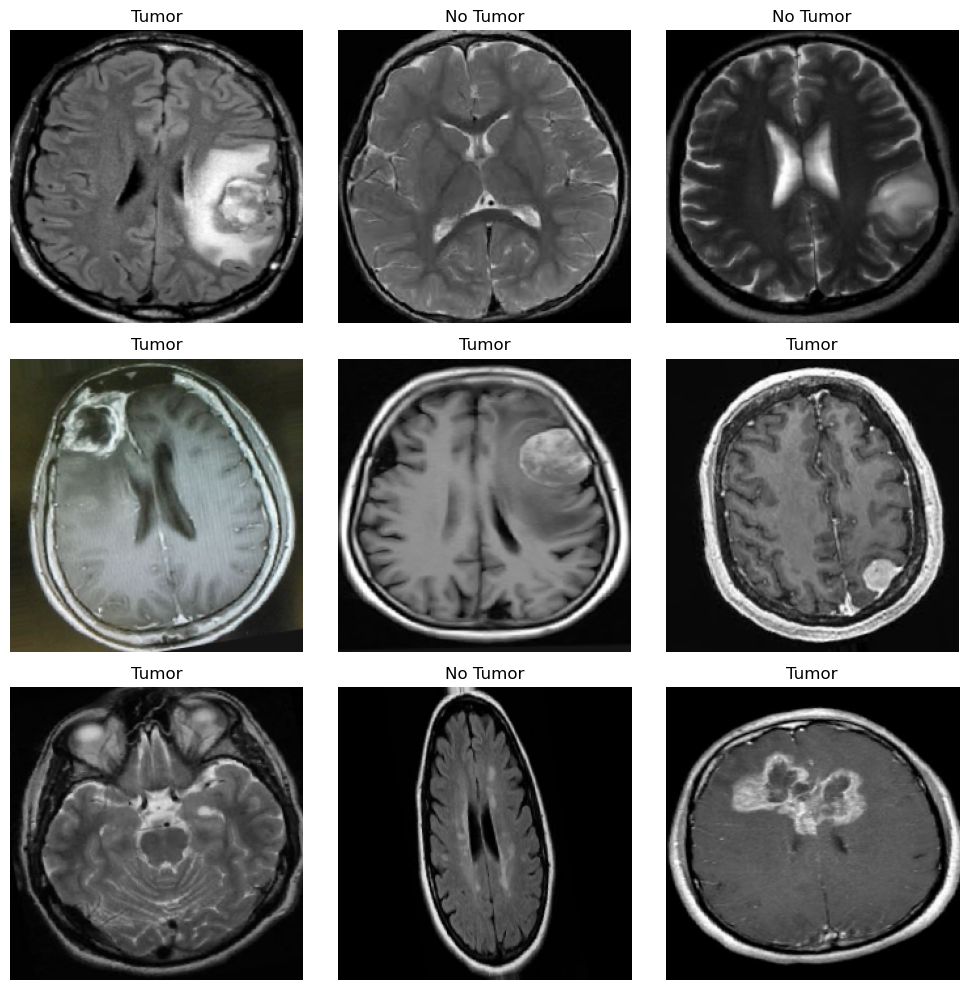

In [20]:
# Get one batch of images

images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):  # show 9 images
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("Tumor" if labels[i] == 1 else "No Tumor")
    plt.axis('off')

plt.tight_layout()
plt.show()

STEP 6 — Add Custom Layers on ResNet

In [30]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [34]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_preact_bn        │ (None, 56, 56, 64)        │             256 │ pool1_pool[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_preact_relu      │ (None, 56, 56, 64)        │               0 │ conv2_block1_preact_bn[0]… │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,096 │ conv2_block1_preact_relu[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_pad            │ (None, 58, 58, 64)        │               0 │ conv2_block1_1_relu[0][0]  │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,864 │ conv2_block1_2_pad[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │               

 Total params: 44,200,965 (168.61 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 42,626,560 (162.61 MB)

 Optimizer params: 1,049,604 (4.00 MB)

STEP 7 — Compile the Model

In [32]:
model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',metrics=['accuracy'])


STEP 8 — Train the Model (IMPORTANT)

In [33]:
history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=10)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.5419 - loss: 0.8035 - val_accuracy: 0.7000 - val_loss: 0.5238
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7044 - loss: 0.5591 - val_accuracy: 0.8600 - val_loss: 0.4205
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7094 - loss: 0.5410 - val_accuracy: 0.9000 - val_loss: 0.3604
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7635 - loss: 0.4977 - val_accuracy: 0.8800 - val_loss: 0.3217
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8177 - loss: 0.4290 - val_accuracy: 0.9000 - val_loss: 0.2975
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.8276 - loss: 0.3639 - val_accuracy: 0.9200 - val_loss: 0.2798
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8621 - loss: 0.3427 - val_accuracy: 0.9200 - val_loss: 0.2691
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8522 - loss: 0.3360 - val_accuracy: 0.9200 - val_loss: 0.2512
Epoch 9/

STEP 9 — Plot Accuracy Graph

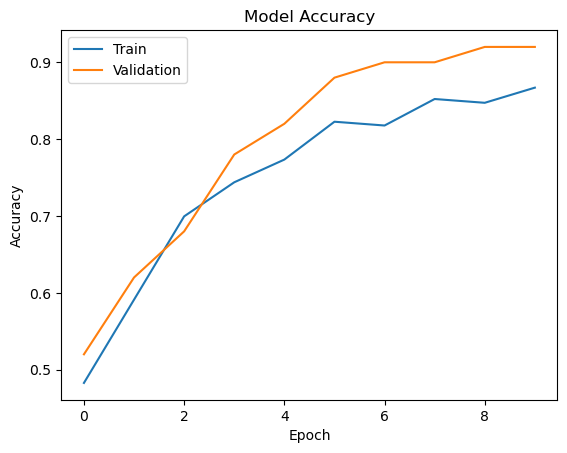

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

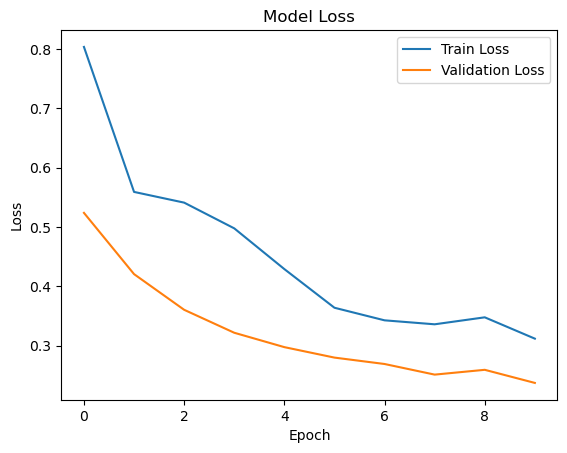

In [36]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

STEP 10 — Confusion Matrix (Project Finishing Touch)

2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 5s/step


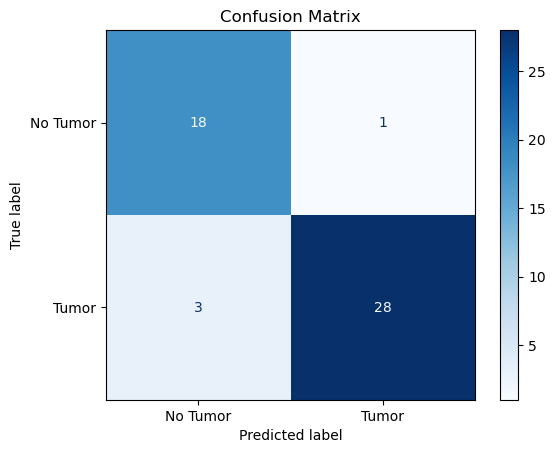

In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on validation set
predictions = model.predict(val_generator)

# Convert probabilities to 0 or 1
pred_labels = (predictions > 0.5).astype(int).reshape(-1)

# True labels
true_labels = val_generator.classes

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Tumor', 'Tumor'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

STEP 11 — Classification Report

In [39]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, pred_labels, target_names=['No Tumor', 'Tumor']))

              precision    recall  f1-score   support

    No Tumor       0.86      0.95      0.90        19
       Tumor       0.97      0.90      0.93        31

    accuracy                           0.92        50
   macro avg       0.91      0.93      0.92        50
weighted avg       0.92      0.92      0.92        50



Conclusion

In this project, a deep learning–based system was developed to detect brain tumors from MRI images using a pretrained ResNet101V2 model. Transfer learning helped extract important image features, and additional layers were added to classify images into tumor and non-tumor categories.

The model was trained and evaluated using accuracy, loss graphs, a confusion matrix, and a classification report. The results showed that the model was able to classify MRI images with good accuracy, demonstrating the effectiveness of deep learning in medical image analysis.

This project highlights how artificial intelligence can assist doctors by providing a fast and supportive tool for early brain tumor detection.